In [1]:
import os
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Sampler, Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torchvision import transforms, models

# ĐỒ ÁN MÔN HỌC: VEHICLE RE-IDENTIFICATION
**Thành viên thực hiện:**
* Chung Tín Đạt - MSSV: 23122024
* Nguyễn Đăng Khôi - MSSV: 23122037

## 1. Khám phá tập dữ liệu VeRi-776
Bài toán Vehicle Re-ID đặt ra thách thức lớn hơn nhiều so với phân loại hình ảnh (Image Classification) thông thường do đặc thù phân bố dữ liệu mở (Open-set).

Tập dữ liệu VeRi-776 chứa:

* **~50,000 hình ảnh** của **776 ID** xe khác nhau.
* Dữ liệu được ghi hình từ mạng lưới **20 camera giám sát** đặt tại các góc giao lộ thực tế.

Cấu trúc tên file VeRi:

[ID_xe]\_[ID_Camera]\_...

In [2]:
data_dir = '/kaggle/input/datasets/abhyudaya12/veri-vehicle-re-identification-dataset/VeRi'

train_dir = os.path.join(data_dir, 'image_train')
test_dir = os.path.join(data_dir, 'image_test')
query_dir = os.path.join(data_dir, 'image_query')

print("Kiểm tra cấu trúc tên file")
count = 0
for img_name in os.listdir(train_dir):
    print(img_name)
    count += 1
    if (count == 10): break

Kiểm tra cấu trúc tên file
0064_c017_00032145_0.jpg
0465_c019_00005325_0.jpg
0230_c016_00073620_0.jpg
0411_c013_00015275_0.jpg
0246_c002_00045820_0.jpg
0274_c012_00062700_0.jpg
0390_c016_00052215_0.jpg
0754_c003_00032560_0.jpg
0201_c008_00057400_0.jpg
0098_c019_00026020_0.jpg


In [3]:
# train_img_size = set()
# test_img_size = set()
# query_img_size = set()

# for img_name in os.listdir(train_dir):
#     if not (img_name.endswith(".jpg")):
#         print(f"{img_name} không hợp lệ!")
#         continue
#     img_path = os.path.join(train_dir, img_name)
#     img = Image.open(img_path)
#     train_img_size.add(img.size)

# for img_name in os.listdir(test_dir):
#     if not (img_name.endswith(".jpg")):
#         print(f"{img_name} không hợp lệ!")
#         continue
#     img_path = os.path.join(test_dir, img_name)
#     img = Image.open(img_path)
#     test_img_size.add(img.size)

# for img_name in os.listdir(query_dir):
#     if not (img_name.endswith(".jpg")):
#         print(f"{img_name} không hợp lệ!")
#         continue
#     img_path = os.path.join(query_dir, img_name)
#     img = Image.open(img_path)
#     query_img_size.add(img.size)

In [4]:
# print("Các kích thước ảnh trong dữ liệu train:", len(train_img_size))
# print("Các kích thước ảnh trong dữ liệu test:", len(test_img_size))
# print("Các kích thước ảnh trong dữ liệu query:", len(query_img_size))

In [5]:
vehicle_freq = defaultdict(lambda: defaultdict(int))

camera_freq = defaultdict(lambda: defaultdict(int))

for img_name in os.listdir(train_dir):
    if not img_name.endswith("jpg"):
        print(f"{img_name} không có đuôi '.jpg'. Bỏ qua!")
        continue
        
    parts = img_name.split('_')
    v_id = parts[0]
    c_id = parts[1]

    vehicle_freq[v_id]["train"] += 1
    camera_freq[c_id]["train"] += 1

for img_name in os.listdir(test_dir):
    if not img_name.endswith("jpg"):
        print(f"{img_name} không có đuôi '.jpg'. Bỏ qua!")
        continue
    
    parts = img_name.split('_')
    v_id = parts[0]
    c_id = parts[1]

    vehicle_freq[v_id]["test"] += 1
    camera_freq[c_id]["test"] += 1

for img_name in os.listdir(query_dir):
    if not img_name.endswith("jpg"):
        print(f"{img_name} không có đuôi '.jpg'. Bỏ qua!")
        continue

    parts = img_name.split('_')
    v_id = parts[0]
    c_id = parts[1]

    vehicle_freq[v_id]["query"] += 1
    camera_freq[c_id]["query"] += 1

vehicle_freq = dict(sorted(vehicle_freq.items()))
camera_freq = dict(sorted(camera_freq.items()))

In [6]:
df_vehicle = pd.DataFrame(vehicle_freq).T
df_vehicle.fillna(0, inplace=True)
display(df_vehicle[(df_vehicle.train != 0) & (df_vehicle.test != 0)])

,train,test,query


Trong VeRi-776, các vehicle ID trong tập **train** và **test** được tách hoàn toàn:
* Một số vehicle ID chỉ xuất hiện trong test set
* Model chưa từng nhìn thấy các ID này trong quá trình huấn luyện
Đây là thiết kế cố ý của bài toán Vehicle Re-Identification (ReID).

Khác với classification thông thường, ReID không yêu cầu model ghi nhớ từng ID cụ thể. Thay vào đó, model phải học:
* Đặc trưng hình ảnh của xe
* Embedding space phân biệt được các xe khác nhau

Vì vậy, test trên các ID chưa từng xuất hiện giúp đánh giá:
* Khả năng tổng quát hóa
( Chất lượng feature embedding
* Khả năng nhận diện đối tượng mới của model

Nếu train và test dùng chung ID:
* Model có thể chỉ học thuộc ID
* Kết quả đánh giá sẽ không phản ánh đúng năng lực ReID thực tế.

Text(0.5, 1.0, 'Biểu đồ cột thể hiện phân bố của xe trong dữ liệu train')

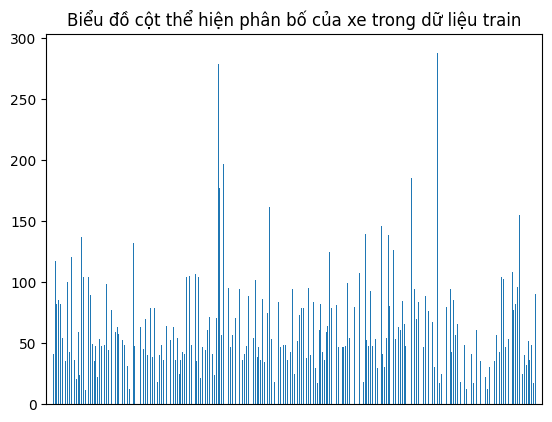

In [7]:
df_vehicle.train.plot(kind='bar')
plt.xticks([])
plt.title("Biểu đồ cột thể hiện phân bố của xe trong dữ liệu train")

In [8]:
df_camera = pd.DataFrame(camera_freq).T
df_camera.fillna(0, inplace=True)
display(df_camera[(df_camera.train != 0) & (df_camera.test != 0)])

,train,test,query
c001,2277.0,688.0,101.0
c002,2122.0,672.0,92.0
c003,2271.0,758.0,109.0
c004,2231.0,687.0,99.0
c005,903.0,295.0,50.0
c006,2034.0,619.0,88.0
c007,749.0,249.0,48.0
c008,1715.0,525.0,87.0
c009,1790.0,565.0,90.0
c010,2040.0,647.0,91.0


Text(0.5, 1.0, 'Biểu đồ cột thể hiện phân bố của camera trong dữ liệu train')

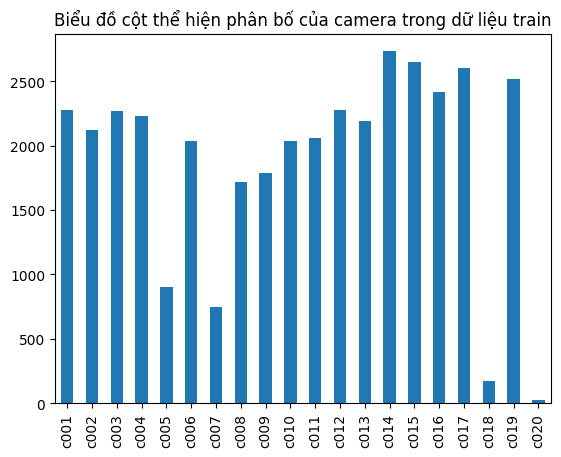

In [9]:
df_camera.train.plot(kind='bar')
plt.title("Biểu đồ cột thể hiện phân bố của camera trong dữ liệu train")

**Thách thức**:
1. **Intra-class Variance:** Một chiếc xe có thể mang diện mạo hoàn toàn khác nhau khi bị chụp bởi các camera khác nhau (thay đổi về góc quay, điều kiện ánh sáng ngày/đêm).
2. **Inter-class Similarity:** Nhiều phương tiện khác ID nhưng lại có kiểu dáng, màu sắc và kích thước gần như tương đồng (đặc biệt là các dòng sedan hoặc xe tải nhỏ).
3. **Occlusion:** Phương tiện thường xuyên bị che lấp bởi các xe khác, cây cối, hoặc biển báo giao thông.

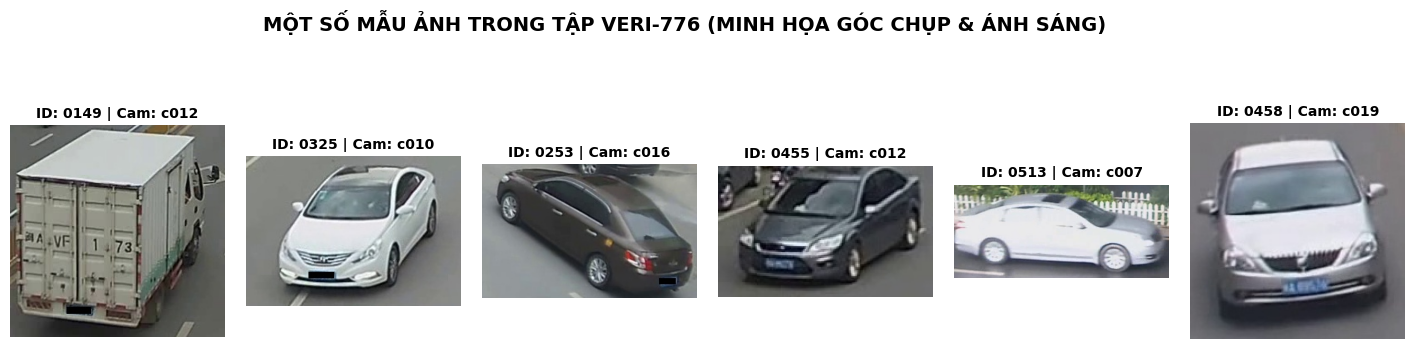

In [10]:
def visualize_dataset_challenges(img_dir, num_samples=6):
    """
    Trích xuất ngẫu nhiên các mẫu ảnh để minh họa độ nhiễu và biến thiên trong tập VeRi-776.
    """
    try:
        all_imgs = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        random.seed(42)
        sample_imgs = random.sample(all_imgs, num_samples, )
        
        fig, axes = plt.subplots(1, num_samples, figsize=(18, 4))
        plt.subplots_adjust(wspace=0.1)
        
        for idx, img_name in enumerate(sample_imgs):
            # Cấu trúc tên file VeRi: [ID_xe]_[ID_Camera]_...
            parts = img_name.split('_')
            v_id = parts[0]
            c_id = parts[1]
            
            img_path = os.path.join(img_dir, img_name)
            img = plt.imread(img_path)
            
            axes[idx].imshow(img)
            axes[idx].set_title(f"ID: {v_id} | Cam: {c_id}", fontweight='bold', fontsize=10)
            axes[idx].axis('off')
            
        plt.suptitle("MỘT SỐ MẪU ẢNH TRONG TẬP VERI-776 (MINH HỌA GÓC CHỤP & ÁNH SÁNG)", fontsize=14, fontweight='bold', y=1.05)
        plt.show()
        
    except Exception as e:
        print(f"Không thể truy cập dữ liệu để vẽ biểu đồ EDA: {e}")

# Kích hoạt hàm trực quan hóa
visualize_dataset_challenges(train_dir)

## 2. Phát biểu bài toán
Bài toán Vehicle Re-Identification (Vehicle ReID) là bài toán truy xuất phương tiện, với mục tiêu xác định xem các ảnh chụp từ nhiều camera khác nhau có thuộc cùng một phương tiện hay không. Khác với bài toán phân loại thông thường, Vehicle ReID không chỉ dự đoán nhãn lớp mà cần học một không gian đặc trưng (embedding space) sao cho các ảnh của cùng một xe nằm gần nhau và các xe khác nhau nằm xa nhau.

### 2.1. Đầu vào và đầu ra của bài toán
1. **Đầu vào:** Ảnh phương tiện được trích xuất từ camera giám sát, trong giai đoạn huấn luyện, mỗi ảnh được gán ID của phương tiện và camera ID tương ứng.
2. **Đầu ra:** Hệ thống sinh ra vector đặc trưng cho mỗi ảnh xe. Khi truy vấn, ảnh query được chuyển thành vector đặc trưng, so sánh với các vector đặc trưng có trong cơ sở dữ liệu (gallery) và trả về danh sách xếp hạng các phương tiện tương đồng với ảnh truy vấn.

### 2.2. Các giai đoạn của mô hình
1. **Giai đoạn Offline:** Huấn luyện mô hình và xây dựng cơ sở dữ liệu đặc trưng.
    1. Huấn luyện mô hình với mục tiêu các ảnh cùng ID phương tiện sẽ có embedding gần nhau, các ảnh khác ID phương tiện có embedding xa nhau.

        Gọi $I$ là ảnh phương tiện đầu vào.
        $$
            I \in \mathbb{R}^{H \times W \times C}
        $$
        Gọi $f(\cdot, \theta)$ là mô hình Vehicle ReID, $\theta$ là tập tham số của mô hình. Mô hình ánh xạ ảnh đầu vào thành vector đặc trưng:
        $$
           E = f(I, \theta)
        $$
        * $E \in \mathbb{R}^d$ với $d$ là số chiều embedding.
    2. Xây dựng cơ sở dữ liệu: Sau khi huấn luyện, classifier head bị loại bỏ, chỉ giữ lại lớp trích xuất đặc trưng. Toàn bộ ảnh gallery được đưa qua mô hình, các vector đặc trưng được lưu lại để phục vụ quá trình truy xuất.

       $$
           G = \{ E_1, E_2, \dots, E_N \}
       $$
       * $N$ là số ảnh trong gallery.
       * $E_i = f(I_i, \theta)$
1. **Giai đoạn Online:** Truy xuất phương tiện từ ảnh truy vấn.
    1. Sinh vector đặc trưng bằng cách đưa ảnh truy vấn vào mô hình.

        $$
            E_q = f(I_q, \theta)
        $$
    2. So sánh với toàn bộ embedding trong gallery bằng độ đo tương đồng (cosine hoặc Euclidean).

        $$
            sim(E_q, E_i) = \frac{E_q \dot E_i}{||E_q|| ||E_i||}
        $$
        * $E_q$: embedding của ảnh truy vấn.
        * $E_i$: embedding của ảnh thứ $i$ trong gallery.
    3. Hệ thống sắp xếp kết quả truy vấn theo độ tương đồng giảm dần và xuất kết quả.

        $$
            R = sort(sim(E_q, E_i))
        $$

## 3. Chiến thuật huấn luyện
Để giải quyết các thách thức của tập VeRi, nhóm cấu hình quá trình huấn luyện theo phương pháp **"Bag of Tricks"** với các tùy chỉnh kỹ thuật:
* **Backbone - ResNet50:** Lựa chọn ResNet50 với trọng số Pre-trained trên ImageNet giúp mô hình kế thừa bộ lọc đặc trưng thị giác cơ bản. Classifier Head được thay thế để khớp với 576 ID xe của tập Train.
* **Multi-objective Loss:**
    * *ID Loss (Cross-Entropy với Label Smoothing):* Đóng vai trò phân loại. Kỹ thuật Label Smoothing giúp mô hình không bị overconfident vào một nhãn, từ đó biểu diễn không gian vector linh hoạt hơn trước các phương tiện giống nhau.
    * *Triplet Loss:* Đóng vai trò Metric Learning. Ép khoảng cách giữa 2 ảnh của cùng một xe (Positive pair) phải nhỏ hơn khoảng cách giữa 2 ảnh của hai xe khác nhau (Negative pair) cộng thêm một biên.
* **Tối ưu hóa Learning Rate (Warmup Strategy):** Sử dụng bộ tối ưu Adam kết hợp Linear Warmup trong 10 Epoch đầu. Việc mồi dần Learning Rate từ thấp lên cao giúp các trọng số mới khởi tạo ở Classifier Head không làm hỏng các đặc trưng tốt đã có ở Backbone, tránh hiện tượng Gradient Explosion.
* **Random Erasing:** Sinh ngẫu nhiên các hình chữ nhật nhiễu che khuất một phần ảnh xe trong lúc train. Phương pháp này ép mạng nơ-ron phải tìm kiếm các đặc trưng cục bộ (đèn xe, mâm xe, logo) thay vì chỉ nhìn vào tổng thể, tăng khả năng chống chịu hiện tượng Occlusion (che khuất) trong thực tế.

### 3.1. Tiền xử lý dữ liệu
Do sử dụng backbone là ResNet50 được huấn luyện trên ImageNet, cần chuẩn hoá dữ liệu ảnh đầu vào RGB theo mean và std của mô hình: $mean = [0.485, 0.456, 0.406]$ và $std = [0.229, 0.224, 0.225]$.

Dữ liệu ảnh đầu vào có kích thước khác nhau, ResNet được thiết kế để có thể xử lý sự khác biệt này, nhưng để thuận tiện cho việc huấn luyện, dữ liệu cần được resize về một kích thước chung để tận dụng batching của Pytorch Tensor. Kích thước được lựa chọn là (256, 256).

Theo kiến trúc ResNet, kích thước feature map sau 4 block tích chập là (H/32, W/32). Với kích thước (256, 256), feature map được tạo ra có kích thước (16, 16).

Ngoài ra, để tăng tính đa dạng cho dữ liệu học, nhóm thực hiện tăng cường dữ liệu cùng che khuất ngẫu nhiên động tại từng vòng lặp huấn luyện (mỗi vòng lặp, dữ liệu sẽ được tăng cường ngẫu nhiên), cụ thể như sau:
* Ngẫu nhiên lật ảnh theo chiều ngang: giúp mô hình khong bị phụ thuộc vào một hướng cụ thể.
* Ngẫu nhiên thay đổi độ sáng và tương phản: giúp mô hình thích ứng với các điều kiện ánh sáng khác nhau của camera.
* Ngẫu nhiên xén (làm nghiêng) ảnh: giúp mô hình thích ứng với góc chụp bị lệch hoặc biến dạng do xe chạy quá nhanh.
* Ngẫu nhiên che khuất: giúp mô hình tránh việc chỉ học các đặc trưng cục bộ, buộc mô hình phải học các đặc điểm tổng quát hơn của toàn bộ đối tượng

### 3.2. Kiến trúc mô hình
Nhóm sử dụng mô hình ResNet50 đã được huấn luyện trước trên tập dữ liệu ImageNet làm backbone cho hệ thống Vehicle ReID. Lớp classifier cuối cùng của ResNet50 được loại bỏ nhằm giữ lại phần mạng tích chập có nhiệm vụ trích xuất đặc trưng ảnh. Việc tận dụng trọng số đã được học từ ImageNet giúp mô hình khai thác hiệu quả các đặc trưng thị giác tổng quát và giảm thời gian huấn luyện trên tập dữ liệu xe cộ.

Trong mô hình ResNet50 gốc, với ảnh (256, 256), feature map có kích thước (16, 16), đây là một không gian nén dữ liệu tương đối nhỏ so với bài toán ReID, do đó nhóm thực hiện thay đổi tham số stride của khối tích chập cuối cùng của backbone (từ stride = 2 thành stride = 1), khi đó kích thước feature map là (32, 32).

Sau backbone ResNet50, nhóm bổ sung thêm một số thành phần để phù hợp với bài toán Vehicle ReID, bao gồm:
1. **Global Average Pooling:** Lớp này thực hiện trung bình hóa toàn bộ giá trị trên mỗi feature map đầu ra của backbone nhằm chuyển đổi dữ liệu đặc trưng từ dạng không gian 2D sang vector đặc trưng 1D. So với việc sử dụng các lớp Fully Connected truyền thống có số lượng tham số lớn, GAP giúp giảm đáng kể số lượng tham số cần huấn luyện, hạn chế hiện tượng overfitting và làm cho mô hình gọn nhẹ hơn.
2. **Batch Normalization:** Sau lớp GAP, Batch Normalization được sử dụng để chuẩn hóa vector đặc trưng về phân phối có trung bình gần bằng 0 và phương sai gần bằng 1. Thành phần này giúp quá trình huấn luyện ổn định hơn, hỗ trợ mô hình hội tụ nhanh hơn và cải thiện khả năng tổng quát hóa trên các phương tiện chưa xuất hiện trong tập huấn luyện. Ngoài ra, BNNeck còn giúp tách biệt quá trình tối ưu giữa bài toán phân loại và bài toán metric learning trong Vehicle ReID.
3. **Classifier Head:** Đây là lớp phân loại tạm thời được sử dụng trong quá trình huấn luyện nhằm tính toán hàm mất mát Cross Entropy cho bài toán nhận dạng ID phương tiện. Tuy nhiên, trong giai đoạn suy luận và truy xuất, lớp này sẽ được loại bỏ và mô hình chỉ sử dụng vector embedding được trích xuất từ backbone để thực hiện so khớp phương tiện.

### 3.3. Hàm mất mát
Nhóm sử dụng kết hợp hai hàm mất mát nhằm tối ưu đồng thời khả năng phân loại và khả năng học không gian đặc trưng cho bài toán Vehicle ReID:

* **ID Loss (Cross Entropy kết hợp Label Smoothing):**

Hàm mất mát này đóng vai trò phân loại ID phương tiện trong quá trình huấn luyện. Thay vì sử dụng nhãn one-hot tuyệt đối, kỹ thuật Label Smoothing phân phối một phần nhỏ xác suất sang các lớp khác, giúp mô hình giảm hiện tượng overconfident đối với dữ liệu huấn luyện. Nhờ đó, vector đặc trưng học được có khả năng tổng quát hóa tốt hơn đối với các phương tiện chưa xuất hiện trong tập kiểm thử.
* **Triplet Loss:**

Hàm mất mát này thuộc nhóm Metric Learning, có nhiệm vụ tối ưu khoảng cách trong không gian embedding. Cụ thể, mô hình được huấn luyện để khoảng cách giữa hai ảnh của cùng một phương tiện (positive pair) nhỏ hơn khoảng cách giữa ảnh của hai phương tiện khác nhau (negative pair) ít nhất một giá trị biên (margin). Điều này giúp các embedding của cùng một xe nằm gần nhau, trong khi embedding của các xe khác nhau được tách biệt rõ ràng hơn trong không gian đặc trưng.

### 3.4. Hàm đánh giá mô hình
Bài toán Vehicle Re-ID thuộc nhóm **Truy vấn tập mở**. Khi triển khai thực tế, hệ thống phải nhận diện những ID xe hoàn toàn mới chưa từng xuất hiện trong tập huấn luyện. Do đó, các chỉ số đánh giá phân loại truyền thống như *Log Loss (Cross-Entropy Loss)* hay *F1-Score* ở pha Test là không có ý nghĩa vì không gian nhãn đã thay đổi.

Hệ thống được đánh giá qua 2 chỉ số tiêu chuẩn của Metric Learning:

1. **Cumulative Matching Characteristics (CMC Curve / Độ chính xác Rank-k):**
* *Ý nghĩa:* Đo lường "tính khả dụng" của hệ thống. Đây là xác suất để chiếc xe cần tìm (True Match) xuất hiện trong tập hợp  $k$ kết quả trả về đầu tiên.
* *Thực tiễn:* Nếu hệ thống có Rank-5 cao, nghĩa là người vận hành (ví dụ: cảnh sát giao thông) chỉ cần kiểm tra 5 ảnh đầu tiên là gần như chắc chắn tìm thấy phương tiện nghi vấn.

2. **Mean Average Precision (mAP):**
* *Ý nghĩa:* Đo lường "độ toàn diện" của mô hình. Một ID xe có thể bị chụp bởi 10 camera khác nhau. Rank-1 chỉ yêu cầu tìm thấy 1 ảnh đúng đầu tiên, nhưng mAP yêu cầu mô hình phải kéo toàn bộ 10 ảnh đó lên các thứ hạng cao nhất.
* mAP phản ánh độ mạnh của hệ thống trước sự biến thiên nội lớp (Intra-class Variance) như đổi góc chụp hay thay đổi ánh sáng.

### 3.5. Các thông số khác
* Balanced Batch Sampler
* Warmup Learning Rate
* Last Stride Modification
* Optimizer: Adam
* Scheduler: Cosine decay + Epoch Warmup
* Learing rate: Backbone: 3e-5, embedding layer + classifier head: 3e-4
* Hyper parameters:
    * Warmup Epochs: 5 - 10
    * Total Epochs: 120
    * Batch Size: 64
    * Images per class: 4

## 4. Cài đặt

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device=}")

device='cuda'


### 4.1. Các kĩ thuật tăng cường dữ liệu

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2),
    transforms.RandomAffine(10, shear=(-10, 10, -10, 10)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(),
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

### 4.2. Hàm đọc ảnh, mô hình Baseline, lớp EarlyStopper, Sampler, Dataset

In [13]:
def read_image(path):
    try:
        img = Image.open(path).convert("RGB")
    except IOError:
        print("IOError incurred when reading")
    
    return img

class VeRiDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples # samples: [[img_path, v_id, c_id], ...]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        img_path, v_id, c_id = self.samples[index]
        v_id = int(v_id)
        c_id = int(c_id[1:])

        img = read_image(img_path)

        if self.transform:
            img = self.transform(img)

        return img, v_id, c_id

    def getImgPath(self):
        paths = []

        for sample in self.samples:
            paths.append(sample[0])

        return paths

    def getImgPath_(self, index):
        return self.samples[index][0]

def create_dataset(dir, transform):
    samples = []
    for img_name in os.listdir(train_dir):
        if not img_name.endswith("jpg"):
            print(f"{img_name} không có đuôi '.jpg'. Bỏ qua!")
            continue
    
        img_path = os.path.join(train_dir, img_name)
        parts = img_name.split('_')
        v_id = parts[0]
        c_id = parts[1]
    
        samples.append([img_path, v_id, c_id])

    return VeRiDataset(samples, transform)

class RandomIdentitySampler(Sampler):
    """
    Randomly samples N identities, then for each identity,
    randomly samples K instances.

    Batch size = N * K
    """
    
    def __init__(self, dataset, batch_size, num_instances):
        """
        Args:
            dataset:
                dataset.samples should contain:
                (img_path, v_id, c_id)

            batch_size:
                total batch size

            num_instances:
                K images per identity
        """

        self.dataset = dataset
        self.batch_size = batch_size
        self.num_instances = num_instances

        self.num_v_ids_per_batch = batch_size // num_instances

        # v_id -> list[index]
        self.index_dic = defaultdict(list)

        for index, (_, v_id, _) in enumerate(dataset.samples):
            self.index_dic[v_id].append(index)

        self.v_ids = list(self.index_dic.keys())

        self.length = 0

        for v_id in self.v_ids:
            idxs = self.index_dic[v_id]

            num = len(idxs)

            if num < self.num_instances:
                num = self.num_instances

            self.length += num - num % self.num_instances

    def __iter__(self):
        batch_idxs_dict = defaultdict(list)

        # prepare mini-batches for each v_id
        for v_id in self.v_ids:
            idxs = self.index_dic[v_id]

            if len(idxs) < self.num_instances:
                idxs = np.random.choice(
                    idxs,
                    size=self.num_instances,
                    replace=True
                )

            idxs = list(idxs)

            random.shuffle(idxs)

            batch_idxs = []

            for idx in idxs:
                batch_idxs.append(idx)

                if len(batch_idxs) == self.num_instances:
                    batch_idxs_dict[v_id].append(batch_idxs)
                    batch_idxs = []

        available_v_ids = list(self.v_ids)

        final_idxs = []

        while len(available_v_ids) >= self.num_v_ids_per_batch:
            selected_v_ids = random.sample(
                available_v_ids,
                self.num_v_ids_per_batch
            )

            for v_id in selected_v_ids:
                batch_idxs = batch_idxs_dict[v_id].pop(0)

                final_idxs.extend(batch_idxs)

                if len(batch_idxs_dict[v_id]) == 0:
                    available_v_ids.remove(v_id)

        return iter(final_idxs)

    def __len__(self):
        return self.length

In [14]:
class BaselineReID(nn.Module):
    def __init__(
        self,
        num_classes,
        embedding_dim=2048,
        pretrained=True,
        last_stride=1,
    ):
        super().__init__()

        # Backbone: Resnet50
        if pretrained:
            weights = models.ResNet50_Weights.IMAGENET1K_V2
        else:
            weights = None

        backbone = models.resnet50(weights=weights)

        # Thay đổi last stride (ở khối thứ 4 của backbone)
        if last_stride == 1:
            backbone.layer4[0].conv2.stride = (1, 1)
            backbone.layer4[0].downsample[0].stride = (1, 1)

        # Loại bỏ classfier head gốc
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Tuỳ chọn
        backbone_dim = 2048

        if embedding_dim != backbone_dim:
            self.embedding = nn.Linear(backbone_dim, embedding_dim)
            feature_dim = embedding_dim
        else:
            self.embedding = nn.Identity()
            feature_dim = backbone_dim

        # Batch Normalization
        self.bnneck = nn.BatchNorm1d(feature_dim)
        self.bnneck.bias.requires_grad_(False)

        # Classifier Head
        self.classifier = nn.Linear(feature_dim, num_classes, bias=False)

        # Tham số khởi tạo theo pytorch (tốt hơn ngẫu nhiên)
        self._init_weights()

    def _init_weights(self):
        if isinstance(self.embedding, nn.Linear):
            nn.init.kaiming_normal_(self.embedding.weight, mode="fan_out")
            nn.init.constant_(self.embedding.bias, 0)

        nn.init.constant_(self.bnneck.weight, 1)
        nn.init.constant_(self.bnneck.bias, 0)

        nn.init.normal_(self.classifier.weight, std=0.001)

    def forward(self, x):
        # Backbone Feature
        feat_map = self.backbone(x)

        # Global Average Pooling
        global_feat = self.gap(feat_map)
        global_feat = global_feat.view(global_feat.shape[0], -1)

        # Embedding
        feat = self.embedding(global_feat)

        # BNNeck
        bn_feat = self.bnneck(feat)

        # Training
        if self.training:
            logits = self.classifier(bn_feat)

            return {
                "triplet_feat": feat,
                "bn_feat": bn_feat,
                "logits": logits
            }

        # Inference
        return bn_feat

class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

### 4.3. Khởi tạo các instance

In [15]:
train_dataset = create_dataset(train_dir, train_transform)
test_dataset = create_dataset(test_dir, test_transform)
query_dataset = create_dataset(query_dir, test_transform)

In [16]:
model = BaselineReID(
    num_classes=776,
    embedding_dim=2048,
    pretrained=True,
    last_stride=1,
)
model.to(device)

early_stopper = EarlyStopper(patience=3, min_delta=10)

sampler = RandomIdentitySampler(
    dataset=train_dataset,
    batch_size=64,
    num_instances=4
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    drop_last=False,
)

query_dataloader = DataLoader(
    query_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    drop_last=False,
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]


### 4.4. Hàm lỗi, validate, Optimizer, Scheduler

In [17]:
def compute_similarity(query_features, gallery_features):
    similarity_matrix = torch.matmul(query_features, gallery_features.T)
    return similarity_matrix

class TripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()

        self.margin = margin

    def forward(self, features, labels):
        n = features.size(0)

        # L2 normalize
        features = nn.functional.normalize(features, p=2, dim=1)

        similarity_matrix = compute_similarity(features, features)

        # Cosine Distance
        dist_matrix = 1 - similarity_matrix

        labels = labels.unsqueeze(1)

        mask_pos = (labels == labels.t())
        mask_pos.fill_diagonal_(False)
        mask_neg = (labels != labels.t())

        # Hardest positive
        dist_ap = torch.max(
            dist_matrix * mask_pos.float(),
            dim=1
        )[0]

        # Hardest negative
        max_dist = dist_matrix.max().max()
        dist_an = torch.min(
            dist_matrix + max_dist * (~mask_neg),
            dim=1
        )[0]

        # loss = max(0, dp - dn + m)
        loss = torch.relu(
            dist_ap - dist_an + self.margin
        )

        return loss.mean()

In [ ]:
def extract_features(model, dataloader):
    model.eval()

    features = []
    labels = []
    camera_ids = []

    with torch.no_grad():
        for images, v_ids, c_ids in tqdm(dataloader):
            images = images.to(device)

            # Forward
            embedding = model(images)

            # L2 normalization
            embedding = nn.functional.normalize(embedding, p=2, dim=1)

            features.append(embedding.cpu())

            labels.extend(v_ids.tolist())
            camera_ids.extend(c_ids.tolist())

    features = torch.cat(features, dim=0)

    return features, labels, camera_ids

def extract_features_(model, image):
    model.eval()

    image = image.to(device)
    image = image[None, :]
    embedding = model(image)
    embedding = nn.functional.normalize(embedding, p=2, dim=1)

    feature = embedding.cpu()
    
    return feature

def evaluate_rank(
    similarity_matrix,
    query_ids,
    gallery_ids,
    query_c_ids,
    gallery_c_ids,
    max_rank=50
):

    num_queries = similarity_matrix.shape[0]

    all_cmc = []
    all_AP = []

    for q_idx in range(num_queries):

        q_id = query_ids[q_idx]
        q_cam = query_c_ids[q_idx]

        sims = similarity_matrix[q_idx]

        # descending similarity
        _, indices = torch.topk(sims, k=max_rank)

        # binary match list
        matches = []

        for idx in indices:

            idx = idx.item()

            g_id = gallery_ids[idx]
            g_cam = gallery_c_ids[idx]

            # remove same-id same-camera
            if q_id == g_id and q_cam == g_cam:
                continue

            matches.append(
                1 if g_id == q_id else 0
            )

        matches = np.asarray(matches)

        # no valid ground truth
        if matches.sum() == 0:
            continue

        # =========================
        # CMC
        # =========================

        first_match_idx = np.where(matches == 1)[0][0]

        cmc = np.zeros(max_rank)

        if first_match_idx < max_rank:
            cmc[first_match_idx:] = 1

        all_cmc.append(cmc)

        # =========================
        # Average Precision
        # =========================

        num_rel = matches.sum()

        tmp_cmc = matches.cumsum()

        precisions = []

        for i in range(len(matches)):

            if matches[i]:

                precision_i = (
                    tmp_cmc[i] / (i + 1)
                )

                precisions.append(precision_i)

        AP = np.sum(precisions) / num_rel

        all_AP.append(AP)

    # =========================
    # Final Metrics
    # =========================

    all_cmc = np.asarray(all_cmc).astype(np.float32)

    mean_cmc = all_cmc.mean(axis=0)

    mAP = np.mean(all_AP)

    return mean_cmc, mAP

def evaluate(model, query_dataloader, test_dataloader):
    q_feat, q_ids, q_cams = extract_features(
        model,
        query_dataloader
    )

    g_feat, g_ids, g_cams = extract_features(
        model,
        test_dataloader
    )

    similarity_matrix = torch.matmul(
        q_feat,
        g_feat.t()
    )

    cmc, mAP = evaluate_rank(
        similarity_matrix,
        q_ids,
        g_ids,
        q_cams,
        g_cams
    )

    return cmc, mAP

In [19]:
margin = 0.3

ce_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
triplet_loss_fn = TripletLoss(margin)

backbone_params = list(model.backbone.parameters())
new_params = (
    list(model.embedding.parameters()) +
    list(model.bnneck.parameters()) +
    list(model.classifier.parameters())
)

optimizer = optim.Adam(
    [
        {
            "params": backbone_params,
            "lr": 3e-5,
        },
        {
            "params": new_params,
            "lr": 3e-4,
        }
    ],
    weight_decay=1e-4
)

MAX_EPOCHS = 15
WARMUP_EPOCHS = 5

warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS,
)

cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS - WARMUP_EPOCHS,
    eta_min=1e-6,
)

scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

### 4.5. Huấn luyện

In [20]:
best_mAP = 0.0
train_loss_hist = []
train_accuracy_hist = []
val_mAP_hist = []
rank_1_hist = []
rank_5_hist = []
rank_10_hist = []

for epoch in range(MAX_EPOCHS):
    model.train()
    
    train_loss = 0.0
    
    correct = 0
    total = 0

    for images, labels, c_ids in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(images)

        logits = outputs["logits"]
        triplet_feat = outputs["triplet_feat"]

        predict = torch.argmax(logits, dim=1)
        correct += (predict == labels).sum().item()
        total += labels.size(0)

        # Losses
        ce_loss = ce_loss_fn(logits, labels)
        triplet_loss = triplet_loss_fn(triplet_feat, labels)

        loss = ce_loss + triplet_loss
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_dataloader)
    train_loss_hist.append(train_loss)
    train_accuracy = correct / total
    train_accuracy_hist.append(train_accuracy)

    # if (epoch + 1) % 5 == 0:
    #     print(f"Start Evaluation at epoch {epoch+1}")
    #     cmc, mAP = evaluate(model, query_dataloader, test_dataloader)
    #     val_mAP_hist.append(mAP)
    #     rank_1_hist.append(cmc[0])
    #     rank_5_hist.append(cmc[4])
    #     rank_10_hist.append(cmc[9])
    #     print("Finish Evaluation")
    
    # if early_stopper.early_stop(mAP):             
    #     break

    # Cập nhật learning rate
    scheduler.step()

    current_lr_backbone = optimizer.param_groups[0]["lr"]
    current_lr_head = optimizer.param_groups[1]["lr"]

    print(
        "=" * 20 + "\n",
        f"Epoch [{epoch+1}/{MAX_EPOCHS}] \n",
        f"Train Loss: {train_loss:.4f} \n",
        # f"Validatation Loss: {val_loss:.4f} \n"
        f"Backbone LR: {current_lr_backbone:.7f} \n",
        f"Head LR: {current_lr_head:.7f} \n\n"
    )

    # if (epoch + 1) % 5 == 0:
    #     print(
    #         f"mAP: {mAP:.4f} \n",
    #         f"Rank-1: {cmc[0]:.4f} \n",
    #         f"Rank-5: {cmc[4]:.4f} \n",
    #         f"Rank-10: {cmc[9]:.4f} \n\n",
    #     )

        # Save Best
        # if mAP > best_mAP:
        #     best_val = mAP
        #     torch.save(model.state_dict(), "baseline_best.pth")

 Epoch [1/15] 
 Train Loss: 6.4890 
 Backbone LR: 0.0000084 
 Head LR: 0.0000840 


 Epoch [2/15] 
 Train Loss: 4.8261 
 Backbone LR: 0.0000138 
 Head LR: 0.0001380 


 Epoch [3/15] 
 Train Loss: 3.2574 
 Backbone LR: 0.0000192 
 Head LR: 0.0001920 


 Epoch [4/15] 
 Train Loss: 2.2079 
 Backbone LR: 0.0000246 
 Head LR: 0.0002460 


 Epoch [5/15] 
 Train Loss: 1.7745 
 Backbone LR: 0.0000300 
 Head LR: 0.0003000 


 Epoch [6/15] 
 Train Loss: 1.5905 
 Backbone LR: 0.0000293 
 Head LR: 0.0002927 


 Epoch [7/15] 
 Train Loss: 1.4817 
 Backbone LR: 0.0000272 
 Head LR: 0.0002714 


 Epoch [8/15] 
 Train Loss: 1.4136 
 Backbone LR: 0.0000240 
 Head LR: 0.0002384 


 Epoch [9/15] 
 Train Loss: 1.3698 
 Backbone LR: 0.0000200 
 Head LR: 0.0001967 


 Epoch [10/15] 
 Train Loss: 1.3335 
 Backbone LR: 0.0000155 
 Head LR: 0.0001505 


 Epoch [11/15] 
 Train Loss: 1.3010 
 Backbone LR: 0.0000110 
 Head LR: 0.0001043 


 Epoch [12/15] 
 Train Loss: 1.2715 
 Backbone LR: 0.0000070 
 Head LR: 0.

### 4.6. Lưu trọng số mô hình

In [21]:
torch.save(model.state_dict(), 'baseline_final.pth')

In [22]:
with open("/kaggle/working/train_loss_hist", "wb") as fp:   #Pickling
    pickle.dump(train_loss_hist, fp)
with open("/kaggle/working/train_accuracy_hist", "wb") as fp:
    pickle.dump(train_accuracy_hist, fp)
with open("/kaggle/working/val_mAP_hist", "wb") as fp:
    pickle.dump(val_mAP_hist, fp)
with open("/kaggle/working/rank_1_hist", "wb") as fp:
    pickle.dump(rank_1_hist, fp)
with open("/kaggle/working/rank_5_hist", "wb") as fp:
    pickle.dump(rank_5_hist, fp)
with open("/kaggle/working/rank_10_hist", "wb") as fp:
    pickle.dump(rank_10_hist, fp)

In [23]:
with open("/kaggle/working/train_loss_hist", "rb") as fp:   # Unpickling
    train_loss_hist = pickle.load(fp)
with open("/kaggle/working/train_accuracy_hist", "rb") as fp:
    train_accuracy_hist = pickle.load(fp)
with open("/kaggle/working/val_mAP_hist", "rb") as fp:
    val_mAP_hist = pickle.load(fp)
with open("/kaggle/working/rank_1_hist", "rb") as fp:
    rank_1_hist = pickle.load(fp)
with open("/kaggle/working/rank_5_hist", "rb") as fp:
    rank_5_hist = pickle.load(fp)
with open("/kaggle/working/rank_10_hist", "rb") as fp:
    rank_10_hist = pickle.load(fp)

## 5. Đánh giá định lượng

Bài toán Vehicle Re-ID thuộc nhóm **Truy vấn tập mở**. Khi triển khai thực tế, hệ thống phải nhận diện những ID xe hoàn toàn mới chưa từng xuất hiện trong tập huấn luyện. Do đó, các chỉ số đánh giá phân loại truyền thống như *Log Loss (Cross-Entropy Loss)* hay *F1-Score* ở pha Test là không có ý nghĩa vì không gian nhãn đã thay đổi.

Hệ thống được đánh giá qua 2 chỉ số tiêu chuẩn của Metric Learning:

**Cumulative Matching Characteristics (CMC Curve / Độ chính xác Rank-k):**
* Ý nghĩa: Đo lường "tính khả dụng" của hệ thống. Đây là xác suất để chiếc xe cần tìm (True Match) xuất hiện trong tập hợp  $k$ kết quả trả về đầu tiên.
* Thực tiễn: Nếu hệ thống có Rank-5 cao, nghĩa là người vận hành (ví dụ: cảnh sát giao thông) chỉ cần kiểm tra 5 ảnh đầu tiên là gần như chắc chắn tìm thấy phương tiện nghi vấn.

**Mean Average Precision (mAP):**
* Ý nghĩa: Đo lường "độ toàn diện" của mô hình. Một ID xe có thể bị chụp bởi 10 camera khác nhau. Rank-1 chỉ yêu cầu tìm thấy 1 ảnh đúng đầu tiên, nhưng mAP yêu cầu mô hình phải kéo toàn bộ 10 ảnh đó lên các thứ hạng cao nhất.
* mAP phản ánh độ mạnh của hệ thống trước sự biến thiên nội lớp (Intra-class Variance) như đổi góc chụp hay thay đổi ánh sáng.

In [24]:
qf, q_ids, q_cams = extract_features(
    model,
    query_dataloader
)

gf, g_ids, g_cams = extract_features(
    model,
    test_dataloader
)

similarity_matrix = torch.matmul(
    qf,
    gf.t()
)

cmc, mAP = evaluate_rank(
    similarity_matrix,
    q_ids,
    g_ids,
    q_cams,
    g_cams
)

print(f"mAP: {mAP:.4f}")
print(f"Rank-1: {cmc[0]:.4f}")
print(f"Rank-5: {cmc[4]:.4f}")
print(f"Rank-10: {cmc[9]:.4f}")

100%|██████████| 591/591 [02:50<00:00,  3.47it/s]


mAP: 0.8068
Rank-1: 0.8510
Rank-5: 0.9305
Rank-10: 0.9641


Text(0.5, 1.0, 'Đồ thị Accuracy của mô hình trong 15 epochs')

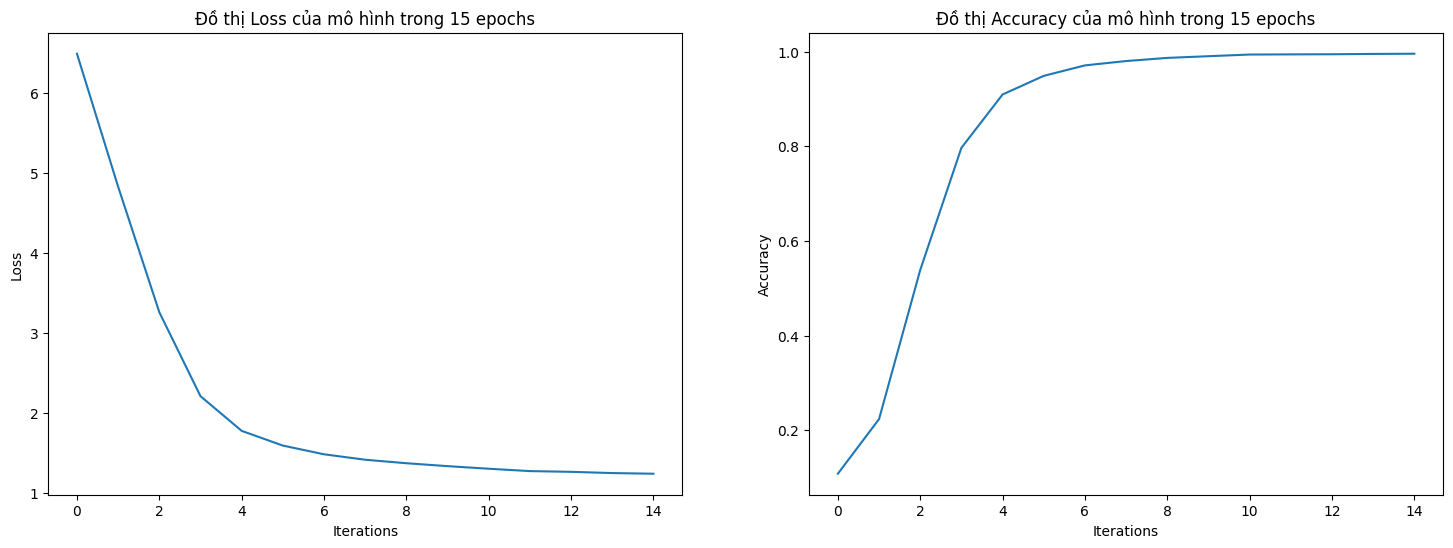

In [25]:
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].plot(train_loss_hist)
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("Loss")
ax[0].set_title(f"Đồ thị Loss của mô hình trong {MAX_EPOCHS} epochs")

ax[1].plot(train_accuracy_hist)
ax[1].set_xlabel("Iterations")
ax[1].set_ylabel("Accuracy")
ax[1].set_title(f"Đồ thị Accuracy của mô hình trong {MAX_EPOCHS} epochs")

In [26]:
# fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# ax[0].plot(val_mAP_hist)
# ax[0].xlabel("Iterations")
# ax[0].ylabel("Mean Average Precision")
# ax[0].title(f"Đồ thị mAP của mô hình trong {MAX_EPOCHS} epochs")

# ax[1].plot(rank_1_hist, label="Rank 1")
# ax[1].plot(rank_5_hist, label="Rank 5")
# ax[1].plot(rank_10_hist, label="Rank 10")
# ax[1].xlabel("Iterations")
# ax[1].ylabel("CMC")
# ax[1].title(f"Đồ thị CMC của mô hình trong {MAX_EPOCHS} epochs")

## 6. Đánh giá định tính

Để kiểm chứng tính hiệu quả thực tế của không gian đặc trưng (Embedding Space) mà mô hình đã học được, nhóm tiến hành thử nghiệm truy vấn (Inference) trực tiếp.

Quy trình thực thi:

1. **Nạp trọng số (Load Weights):** Sử dụng trọng số từ tệp `baseline_final.pth`.
2. **Trích xuất Đặc trưng (Feature Extraction):** Ảnh Query và các ảnh Gallery được đưa qua mạng ResNet50 để lấy ra vector đặc trưng 2048 chiều.
3. **Tính toán Khoảng cách (Distance Metric):** Sử dụng Khoảng cách Cosine (Cosine Distance) để so khớp độ tương đồng giữa vector Query và tập vector Gallery.
4. **Truy xuất (Retrieval):** Sắp xếp khoảng cách tăng dần để lấy ra Top-5 kết quả gần nhất. Kết quả viền Xanh thể hiện tìm đúng xe (True Match), viền Đỏ thể hiện tìm sai xe (False Match).

100%|██████████| 591/591 [02:59<00:00,  3.29it/s]


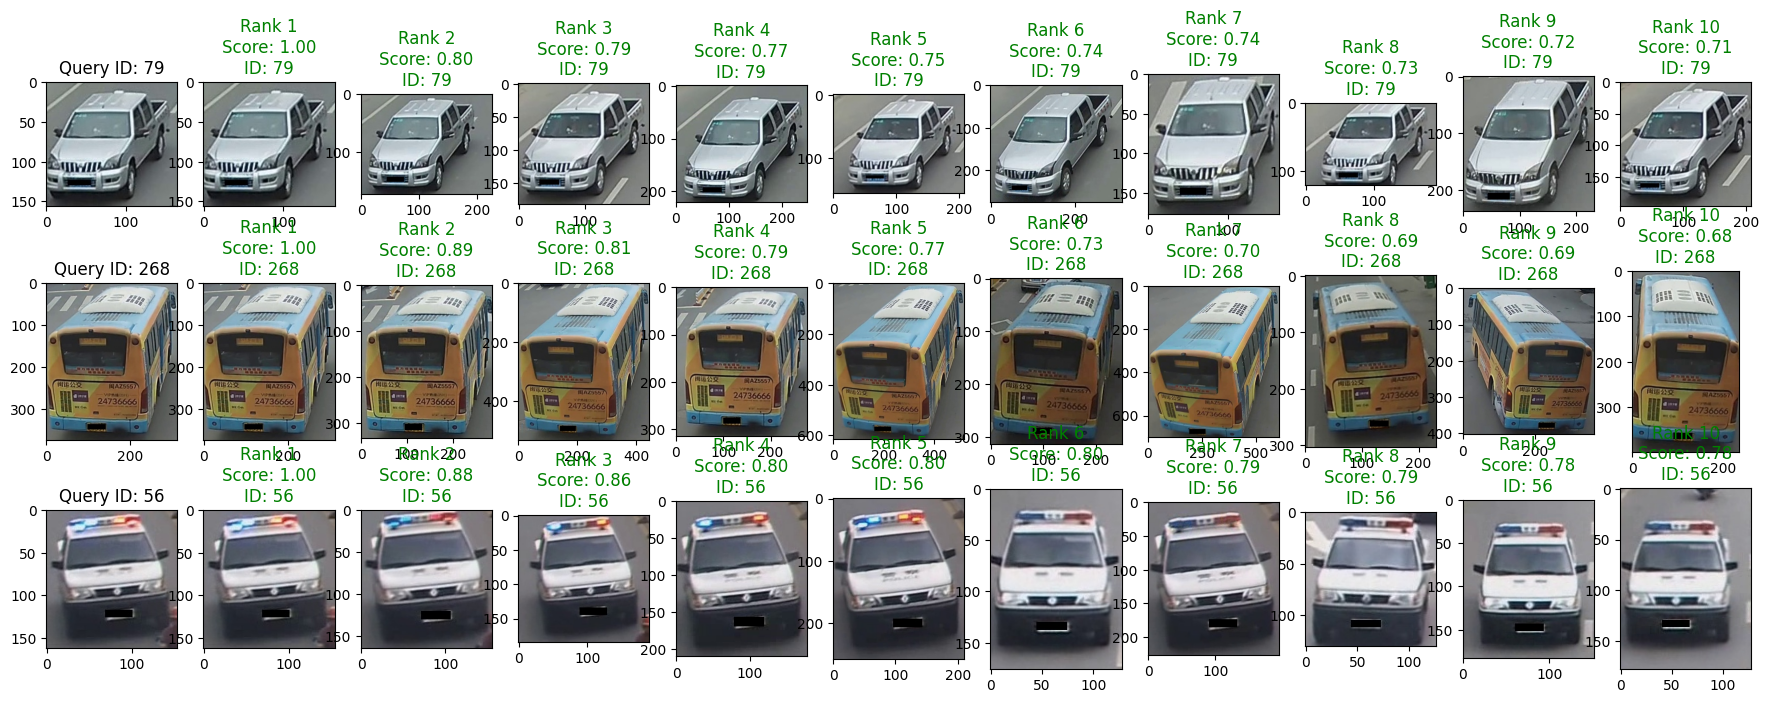

In [ ]:
# Nạp trọng số
model = BaselineReID(
    num_classes=776,
    embedding_dim=2048,
    pretrained=True,
    last_stride=1,
)
state_dict = torch.load('/kaggle/working/baseline_final.pth', weights_only=True, map_location='cpu')
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# Trích xuất đặc trưng Gallery
gallery_features, gallery_v_ids, gallery_c_ids = extract_features(model, test_dataloader)
gallery_img_paths = test_dataset.getImgPath()

# Trích xuất đặc trưng Query
n_samples = 3
random_indices = random.sample(range(len(query_dataloader)), n_samples)

query_features = []
query_v_ids = []
query_c_ids = []
query_img_paths = []

for index in random_indices:
    img, v_id, c_id = query_dataset[index]
    query_features.append(extract_features_(model, img))
    query_v_ids.append(v_id)
    query_c_ids.append(c_id)
    query_img_paths.append(query_dataset.getImgPath_(index))

# Truy xuất
n_top = 10

fig, ax = plt.subplots(n_samples, n_top + 1, figsize=(22, 8))

for i in range(n_samples):
    features = query_features[i]

    sim_score = compute_similarity(features, gallery_features)

    top_sim_score, top_index = torch.sort(sim_score, descending=True)
    top_sim_score = top_sim_score[:n_top]
    top_sim_score = top_sim_score.squeeze(0)
    top_index = top_index[:n_top]
    top_index = top_index.squeeze(0)

    retrieval_v_ids = [gallery_v_ids[index.item()] for index in top_index]
    retrieval_c_ids = [gallery_c_ids[index.item()] for index in top_index]
    retrieval_img_paths = [gallery_img_paths[index.item()] for index in top_index]

    ax[i][0].imshow(plt.imread(query_img_paths[i]))
    ax[i][0].set_title(f"Query ID: {query_v_ids[i]}")
    for j in range(n_top):
        color = "green" if query_v_ids[i] == retrieval_v_ids[j] else "red"
        ax[i][j + 1].imshow(plt.imread(retrieval_img_paths[j]))
        ax[i][j + 1].set_title(f"Rank {j + 1}\nScore: {top_sim_score[j]:.2f}\nID: {retrieval_v_ids[j]}", color=color)

plt.show()

In [ ]:
n_top = 10

gallery_features, gallery_v_ids, gallery_c_ids = extract_features(
    model,
    test_dataloader
)

gallery_img_paths = test_dataloader.getImgPath()

query_features, query_v_ids, query_c_ids = extract_features(
    model,
    query_dataloader
)

query_img_paths = query_dataloader.getImgPath()

similarity_matrix = compute_similarity(
    query_features,
    gallery_features
)

# (num_query, n_top)
top_sim_score, top_index = torch.topk(
    similarity_matrix,
    k=n_top,
    dim=1
)

retrieval_miss_indices = []

for i in range(len(query_v_ids)):

    q_id = query_v_ids[i]

    success = False

    for j in range(n_top):

        g_index = top_index[i, j].item()
        g_id = gallery_v_ids[g_index]

        if q_id == g_id:
            success = True
            break

    if not success:
        retrieval_miss_indices.append(i)

print(f"Number of retrieval misses: {len(retrieval_miss_indices)}")

In [ ]:
n_show = min(10, len(retrieval_miss_indices))

fig, ax = plt.subplots(
    n_show,
    n_top + 1,
    figsize=(20, 2 * n_show)
)

if n_show == 1:
    ax = [ax]

for row, q_idx in enumerate(retrieval_miss_indices[:n_show]):

    ax[row][0].imshow(
        plt.imread(query_img_paths[q_idx])
    )

    ax[row][0].set_title(
        f"Query\nID: {query_v_ids[q_idx]}"
    )

    ax[row][0].axis("off")

    for j in range(n_top):

        g_idx = top_index[q_idx, j].item()

        g_id = gallery_v_ids[g_idx]

        color = (
            "green"
            if g_id == query_v_ids[q_idx]
            else "red"
        )

        ax[row][j + 1].imshow(
            plt.imread(gallery_img_paths[g_idx])
        )

        ax[row][j + 1].set_title(
            f"Rank {j+1}\n"
            f"ID: {g_id}\n"
            f"{top_sim_score[q_idx, j]:.3f}",
            color=color
        )

        ax[row][j + 1].axis("off")

## 7. Ablation Study
* Giữ nguyên stride của backbone
* Không tăng cường dữ liệu
* Không bag of tricks
* Thay đổi optimizer
* Thay đổi Scheduler
* Thay đổi hyper parameters
* Thay đổi Loss function từ Triplet thành Circle